# Notebook 1: N-grams and the Sparsity Problem

> **Article section:** *Part 1 — The Statistical Era*

In this notebook we'll build an N-gram model completely from scratch : no libraries, just Python and math.  
By the end, you'll see *exactly* why N-grams hit a wall, and why Laplace smoothing is a patch rather than a real fix.

---
**What we cover:**
1. Tokenize a corpus
2. Build unigram, bigram, and trigram probability tables
3. Visualise the sparsity problem
4. Add Laplace smoothing and compare
5. Generate text and see its limitations
---

In [22]:
import os, sys

# Step 1 - clone again
!git clone https://github.com/ArpitaRPatki/-nlp-evolution-explained.git /content/nlp-evolution-explained

# Step 2 - move into it
os.chdir('/content/nlp-evolution-explained')
repo_root = '/content/nlp-evolution-explained'

# Step 3 - add to path
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Step 4 - install packages
!pip install -q gensim transformers torch scikit-learn seaborn

# Step 5 - confirm
print("\nWorking directory:", os.getcwd())
print("Contents:", os.listdir())

Cloning into '/content/nlp-evolution-explained'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 45 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 33.49 KiB | 1.05 MiB/s, done.
Resolving deltas: 100% (13/13), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.4 MB/s eta 0:00:00

Working directory: /content/nlp-evolution-explained
Contents: ['.git', 'data', 'README.md', 'requirements.txt', 'notebooks', 'outputs', '.gitignore', 'src']


In [12]:
# Standard library imports — no pip install needed for this cell
import re
import math
import sys
import os
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Allow imports from src/
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print('All imports OK.')

All imports OK.


In [23]:
import os
print("Current directory:", os.getcwd())
print("Contents here:", os.listdir())

Current directory: /content/nlp-evolution-explained
Contents here: ['.git', 'data', 'README.md', 'requirements.txt', 'notebooks', 'outputs', '.gitignore', 'src']


## 1. Load and tokenise the corpus

In [24]:
corpus_path = '/content/nlp-evolution-explained/data/sample_corpus.txt'

with open(corpus_path, 'r') as f:
    raw_lines = f.readlines()

def tokenize(text: str):
    """Lowercase and split on non-alphabetic characters."""
    text = text.lower().strip()
    tokens = re.findall(r"[a-z']+", text)
    return tokens

sentences = [tokenize(line) for line in raw_lines if line.strip()]

print(f'Loaded {len(sentences)} sentences.')
print(f'Example: {sentences[0]}')

Loaded 20 sentences.
Example: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'near', 'the', 'river', 'bank']


## 2. Build probability tables manually

Before using our clean `NGramModel` class, let's build the tables by hand so you can see exactly what's happening.

In [25]:
# ---- UNIGRAM model ----
all_tokens = [token for sent in sentences for token in sent]
unigram_counts = Counter(all_tokens)
total_tokens = sum(unigram_counts.values())

print(f'Total tokens: {total_tokens}')
print(f'Vocabulary size: {len(unigram_counts)}')
print()
print('Top 10 most common words (unigrams):')
for word, count in unigram_counts.most_common(10):
    prob = count / total_tokens
    print(f'  {word:15s}  count={count:3d}  P={prob:.4f}')

Total tokens: 204
Vocabulary size: 131

Top 10 most common words (unigrams):
  the              count= 32  P=0.1569
  bank             count=  7  P=0.0343
  and              count=  6  P=0.0294
  river            count=  4  P=0.0196
  a                count=  4  P=0.0196
  cat              count=  3  P=0.0147
  on               count=  3  P=0.0147
  mat              count=  3  P=0.0147
  fox              count=  3  P=0.0147
  language         count=  3  P=0.0147


In [26]:
# ---- BIGRAM model ----
bigram_counts = defaultdict(Counter)

for sent in sentences:
    padded = ['<s>'] + sent + ['</s>']
    for i in range(len(padded) - 1):
        context = padded[i]
        next_word = padded[i + 1]
        bigram_counts[context][next_word] += 1

def bigram_probability(context, word, smoothing=0.0):
    vocab_size = len(unigram_counts) + 2  # +2 for <s>, </s>
    count_cw = bigram_counts[context].get(word, 0)
    count_c  = sum(bigram_counts[context].values())
    return (count_cw + smoothing) / (count_c + smoothing * vocab_size + 1e-9)

# Demonstrate
test_word = 'bank'
print(f"P(bank | 'the')  = {bigram_probability('the', 'bank'):.4f}")
print(f"P(river | 'the') = {bigram_probability('the', 'river'):.4f}")
print(f"P(cat | 'the')   = {bigram_probability('the', 'cat'):.4f}")

P(bank | 'the')  = 0.0625
P(river | 'the') = 0.1250
P(cat | 'the')   = 0.0937


## 3. Visualise the Sparsity Problem

Let's plot the bigram probability table as a heatmap.  
Notice how most cells are **zero** — that's the sparsity problem.

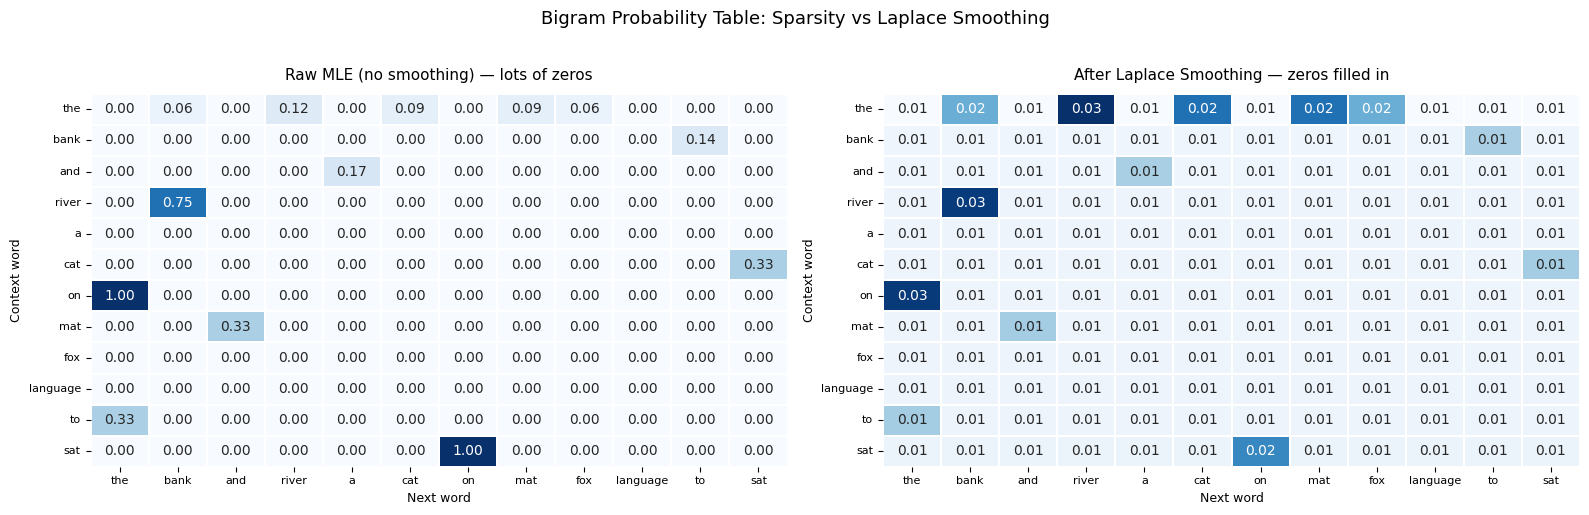

Figure saved to outputs/01_sparsity_heatmap.png


In [31]:
# Use the 12 most common words to build a visible matrix
top_words = [w for w, _ in unigram_counts.most_common(12)]

matrix = np.zeros((len(top_words), len(top_words)))
for i, context in enumerate(top_words):
    for j, word in enumerate(top_words):
        matrix[i, j] = bigram_probability(context, word)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, title, smooth in zip(
    axes,
    ['Raw MLE (no smoothing) — lots of zeros', 'After Laplace Smoothing — zeros filled in'],
    [0.0, 1.0]
):
    m = np.zeros((len(top_words), len(top_words)))
    for i, ctx in enumerate(top_words):
        for j, w in enumerate(top_words):
            m[i, j] = bigram_probability(ctx, w, smoothing=smooth)

    sns.heatmap(
        m,
        ax=ax,
        xticklabels=top_words,
        yticklabels=top_words,
        cmap='Blues',
        annot=True,
        fmt='.2f',
        linewidths=0.3,
        cbar=False,
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel('Next word', fontsize=9)
    ax.set_ylabel('Context word', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(
    'Bigram Probability Table: Sparsity vs Laplace Smoothing',
    fontsize=13, fontweight='medium', y=1.02
)
plt.tight_layout()
plt.savefig('/content/nlp-evolution-explained/outputs/01_sparsity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/01_sparsity_heatmap.png')

## 4. N-gram Language Model class

Now let's use the clean `NGramModel` from `src/` to train bigram and trigram models.

In [34]:
import re
import math
import os, sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

repo_root = '/content/nlp-evolution-explained'
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.ngram_model import NGramModel

print('All imports OK.')

All imports OK.


In [35]:
# Train models with and without smoothing
bigram_mle    = NGramModel(n=2, smoothing=0.0).fit(sentences)
bigram_smooth = NGramModel(n=2, smoothing=1.0).fit(sentences)
trigram_mle   = NGramModel(n=3, smoothing=0.0).fit(sentences)

print('Models fitted:', bigram_mle, bigram_smooth, trigram_mle, sep='\n  ')

Models fitted:
  NGramModel(n=2, smoothing=0.0, status=fitted)
  NGramModel(n=2, smoothing=1.0, status=fitted)
  NGramModel(n=3, smoothing=0.0, status=fitted)


In [36]:
# What comes after 'the'?
print('Top words after "the" (bigram, MLE):')
for word, prob in bigram_mle.get_top_next_words(('the',), top_k=8):
    print(f'  {word:15s}  P={prob:.4f}')

Top words after "the" (bigram, MLE):
  river            P=0.1250
  cat              P=0.0938
  mat              P=0.0938
  bank             P=0.0625
  fox              P=0.0625
  lazy             P=0.0312
  loan             P=0.0312
  documents        P=0.0312


In [37]:
# Demonstrate that 'bank' has NO semantic understanding in N-grams
# The model gives the same next-word distribution regardless of meaning

print('Top words after "bank" (bigram, MLE):')
print('  (Notice: no distinction between river bank vs financial bank)')
for word, prob in bigram_mle.get_top_next_words(('bank',), top_k=8):
    print(f'  {word:15s}  P={prob:.4f}')

Top words after "bank" (bigram, MLE):
  (Notice: no distinction between river bank vs financial bank)
  </s>             P=0.1429
  approved         P=0.1429
  at               P=0.1429
  to               P=0.1429
  was              P=0.1429
  closed           P=0.1429
  watching         P=0.1429


## 5. Generate text

Let's generate some sentences. You'll notice the N-gram model produces grammatically reasonable but semantically hollow text.

In [38]:
import random
random.seed(7)

print('Generated sentences from bigram model:')
for _ in range(5):
    print(' >', bigram_mle.generate(max_words=12))

print()
print('Generated sentences from trigram model:')
for _ in range(5):
    print(' >', trigram_mle.generate(max_words=12))

Generated sentences from bigram model:
 > the mat and felt at sunset and grace
 > the cat sat on the mat near the table near the window
 > the national holiday
 > the river flow slowly
 > she walked together through the river bank at sunset and into the

Generated sentences from trigram model:
 > language models learn patterns by reading large amounts of text
 > language models learn patterns by reading large amounts of text
 > she walked along the river bank
 > i went to the bank approved the loan after reviewing the documents
 > language models learn patterns by reading large amounts of text


## 6. Key takeaways

| Problem | Description | Fixed by N-gram? |
|---------|-------------|------------------|
| **Sparsity** | Unseen sequences get zero probability | Partially — Laplace helps |
| **No semantic understanding** | "bank" (river) = "bank" (money) | ❌ No |
| **Short memory** | Can't track dependencies > n words back | ❌ No |
| **No world knowledge** | Doesn't know a fox is an animal | ❌ No |

**Next:** We'll see how Word2Vec gives words *meaning* by representing them as vectors.